#### Import Libraries

In [19]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from collections import Counter

#### Parsing ligands files

In [20]:
def parse_ligands(sdf_path, label):
    suppl = Chem.SDMolSupplier(sdf_path)
    data = []

    for mol in suppl:
        if mol is None:
            continue

        atoms = [atom.GetSymbol() for atom in mol.GetAtoms()]
        atom_counts = Counter(atoms)

        features = {
            'MolWt': Descriptors.MolWt(mol),
            'LogP': Descriptors.MolLogP(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol),
            'TPSA': Descriptors.TPSA(mol),
            'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
            'RingCount': Descriptors.RingCount(mol),
            'Label': label
        }

        for atom in ['C', 'H', 'O', 'N', 'S', 'P', 'F', 'Cl', 'Br', 'I']:
            features[f'Atom_{atom}'] = atom_counts.get(atom, 0)
        data.append(features)

    return pd.DataFrame(data)

##### Extract and combine features

In [23]:
df_drugs = parse_ligands("drugs.sdf", label='drug like')

# Non-druglike ligands
df_nondrugs = parse_ligands("nondrugs.sdf", label='not drug like')

# Combine
df_all = pd.concat([df_drugs, df_nondrugs], ignore_index=True).sample(frac=1).reset_index(drop=True)


#### Save to CSV

In [24]:
df_all.to_csv("ligand_features_dataset.csv", index=False)

print("[✓] Dataset saved as 'ligand_features_dataset.csv'")

print(df_all.head())

[✓] Dataset saved as 'ligand_features_dataset.csv'
     MolWt    LogP  NumHDonors  NumHAcceptors   TPSA  NumRotatableBonds   
0  486.436  4.6081           4              6  91.18                 16  \
1  192.268  3.1552           0              4  24.72                  2   
2  329.125  1.4064           2              3  67.43                  1   
3  163.198 -0.4945           3              3  66.40                  3   
4  327.468  4.1437           2              3  52.82                  1   

   RingCount          Label  Atom_C  Atom_H  Atom_O  Atom_N  Atom_S  Atom_P   
0          2      drug like      24       0       5       1       0       0  \
1          1  not drug like       8       0       0       2       2       0   
2          3  not drug like      12       0       3       2       0       0   
3          0      drug like       5       0       3       1       1       0   
4          4      drug like      21       0       2       1       0       0   

   Atom_F  Atom_Cl  Ato

#### Train and test model

In [29]:
X = df_all.drop("Label", axis=1)
y = df_all["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


#### Print results

In [30]:
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred) )
print('\n Classification Report:'  )
print(classification_report(y_test, y_pred) )

Confusion matrix:
[[19  5]
 [ 1 15]]

 Classification Report:
               precision    recall  f1-score   support

    drug like       0.95      0.79      0.86        24
not drug like       0.75      0.94      0.83        16

     accuracy                           0.85        40
    macro avg       0.85      0.86      0.85        40
 weighted avg       0.87      0.85      0.85        40



###### Accuracy = 0.85 → 85% of predictions are correct
###### Drug-like (positive class):
###### High precision (0.95) → Most predicted drugs are actually drugs 
###### Moderate recall (0.79) → Some real drugs are being missed 
###### Non-drug-like (negative class):
###### Moderate precision (0.75) → Some predicted non-drugs are actually drugs 
###### Good recall (0.94) → It’s catching most of the actual non-drugs

#### Visualize results

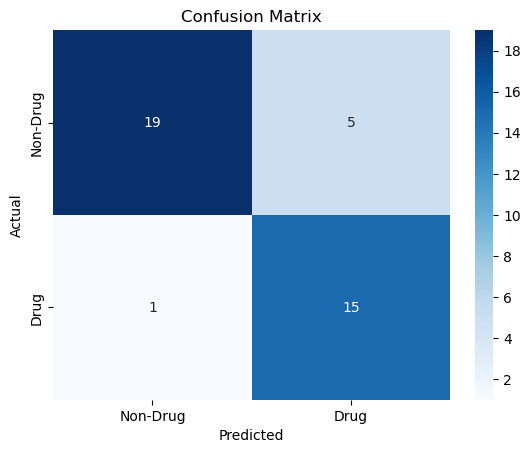

In [31]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Drug', 'Drug'], yticklabels=['Non-Drug', 'Drug'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

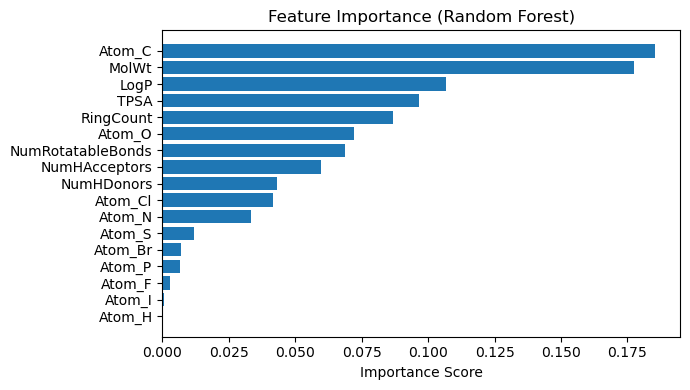

In [32]:
importances = clf.feature_importances_
features = X.columns
sorted_idx = importances.argsort()

plt.figure(figsize=(7, 4))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), features[sorted_idx])
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()